In [1]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_phi2D_data(directory_path);

Found 26401 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Compiled data from 3000 files...
Compiled data from 4000 files...
Compiled data from 5000 files...
Compiled data from 6000 files...
Compiled data from 7000 files...
Compiled data from 8000 files...
Compiled data from 9000 files...
Compiled data from 10000 files...
Compiled data from 11000 files...
Compiled data from 12000 files...
Compiled data from 13000 files...
Compiled data from 14000 files...
Compiled data from 15000 files...
Compiled data from 16000 files...
Compiled data from 17000 files...
Compiled data from 18000 files...
Compiled data from 19000 files...
Compiled data from 20000 files...
Compiled data from 21000 files...
Compiled data from 22000 files...
Compiled data from 23000 files...
Compiled data from 24000 files...
Compiled data from 25000 files...
Compiled data from 26000 files...
Finished compiling data from all files in the directory.


<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_968603/3504677053.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Frequency [Hz]" if real_frequency else f"Frequency [$\omega_ci$]");


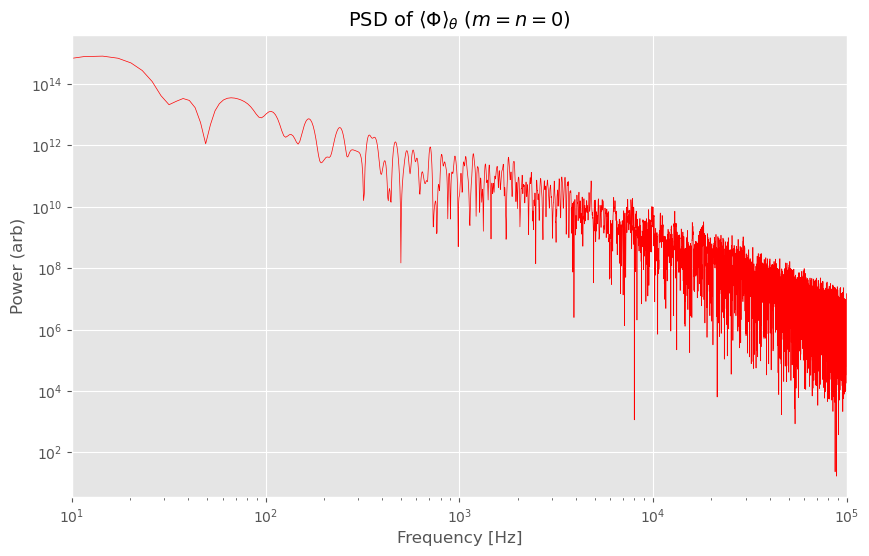

In [9]:
def plot_power_spectrum_density(phi2D_list, delta_t, effective_radius = 0.7, real_frequency = False):

	# Signal isolation and data processing.
	# Logic here is similar to that of `extract_GAM_frequency` in the utilities.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);
	frequencies, power_spectrum_density = utils.map_power_spectrum(radial_time_series, delta_t);
	frequencies = utils.convert_to_real_frequency(frequencies) if real_frequency else frequencies;
	GAM_peak_index = utils.isolate_GAM_peak_index(power_spectrum_density, frequencies);
	GAM_frequency = frequencies[GAM_peak_index];
	GAM_power = float(power_spectrum_density[GAM_peak_index]);
	
	# Figure plotting logic.
	plt.figure(figsize = (10, 6));
	plt.loglog(frequencies, power_spectrum_density, label = "PSD", color = "red", lw = 0.5);
	#plt.vlines(GAM_frequency, GAM_power, 0, colors = "black", linestyles = "dotted");
	#plt.plot(GAM_frequency, power_spectrum_density[GAM_peak_index], "ro");
	#plt.annotate(f"GAM peak: {GAM_frequency/1e3 : .2f} kHz", xy = (GAM_frequency, GAM_power), xytext = (GAM_frequency * 1.1, GAM_power * 1.5));
	plt.xlabel("Frequency [Hz]" if real_frequency else f"Frequency [$\omega_ci$]");	
	plt.ylabel("Power (arb)");
	plt.xlim(10, 1e5);
	plt.title(r"PSD of $\langle \Phi \rangle_\theta$ ($m = n = 0$)", fontsize = 14);
	plt.show();

plot_power_spectrum_density(data_arrays, delta_t, real_frequency = True);